###**DIP Practical-7**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

**Objective:**

To write and execute a program for Fourier transform on a given image and perform inverse Fourier transform to reconstruct the image.

**To-do:**
1. Convert the spatial domain image into the frequency domain using the 2D Fast Fourier Transform (FFT).
2. Visualize the magnitude spectrum.
3. Apply the Inverse Fast Fourier Transform (IFFT) to reconstruct the original image from its frequency components.

**1. Import libraries and image**

In [1]:
#import libraries needed
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

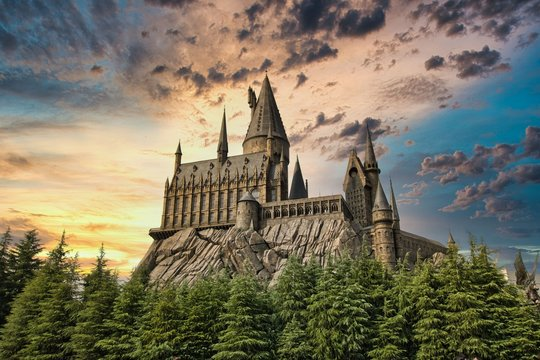

In [2]:
#load and show original image
img=cv2.imread('hogwarts image.jpg')
cv2_imshow(img)

**Pre-req: convert image to grayscale**

Fourier transform is typically performed on grayscale images to analyze the 2D spatial frequency content without the added complexity of color channels.

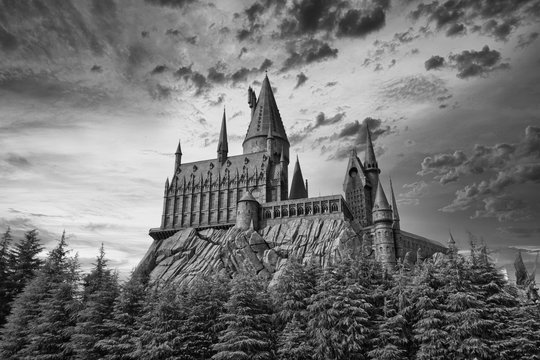

In [3]:
#convert to grayscale
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

**2. 2D Fourier Transform and Frequency Shifting**

The Fourier Transform converts the image from the spatial domain to the frequency domain. Mathematically, the 2D Discrete Fourier Transform is given by: $$F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y) e^{-j2\pi(ux/M + vy/N)}$$

Using NumPy's Fast Fourier Transform `(np.fft.fft2)`, we compute the frequency components. By default, the zero-frequency component (DC component, representing the average brightness) is located at the top-left corner. To make the frequency spectrum easier to interpret and process, we use `np.fft.fftshift` to shift this zero-frequency component to the geometric center of our spectrum.

In [4]:
#compute the 2D Fast Fourier Transform (FFT)
f_transform = np.fft.fft2(gray)

#shift the zero-frequency component (DC component) to the center of the spectrum
f_shift = np.fft.fftshift(f_transform)

print("Fourier Transform and shift completed.")

Fourier Transform and shift completed.


**3. Calculating and Visualizing the Magnitude Spectrum**

The output of the Fourier transform is a matrix of complex numbers. To visualize it as an image, we need to compute its magnitude. Because the dynamic range of Fourier coefficients is extremely large (the DC component at the center is usually orders of magnitude larger than high-frequency components), simply plotting the absolute values will result in an almost entirely black image with a single white pixel.To fix this, we apply a logarithmic transformation: $$S = c \cdot \log(1 + |F(u,v)|)$$ This compresses the dynamic range, making the high-frequency details visible.

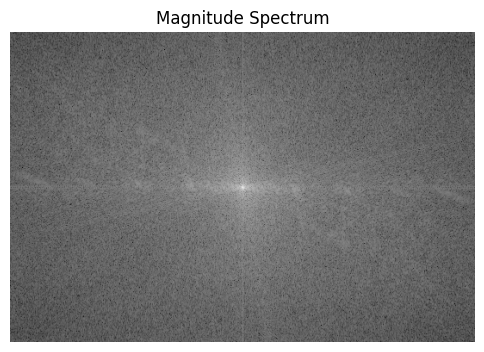

In [6]:
#calculate the magnitude spectrum
#we add 1 to np.abs(f_shift) to avoid taking the log of 0 (which yields negative infinity)
#multiplying by 20 is a standard scaling factor to map the values into a visible range (0-255)
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

#display the magnitude spectrum
plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off') #hide axes for better visual presentation
plt.show()

**4. Inverse Fourier Transform**

To reconstruct the original image from the frequency domain, we must reverse our previous steps. First, we shift the zero-frequency component back to its original position at the top-left corner using `np.fft.ifftshift`. Then, we apply the Inverse 2D Fast Fourier Transform (`np.fft.ifft2`).

The result of the inverse transform is still a complex array (due to minor floating-point inaccuracies during computation). We extract the real part or take the absolute magnitude (`np.abs`) to recover the final spatial domain image.

Inverse Fourier Transform and image reconstruction completed

Reconstructed image:


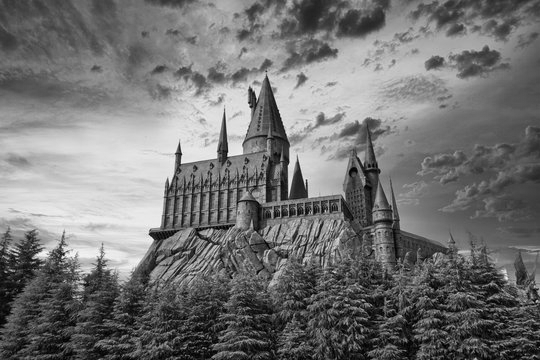

In [9]:
#1. shift the zero-frequency component back to the top-left corner
f_ishift = np.fft.ifftshift(f_shift)

# 2. perform the Inverse 2D Fast Fourier Transform
img_back_complex = np.fft.ifft2(f_ishift)

# 3. extract the absolute magnitude to get the real reconstructed image
img_reconstructed = np.abs(img_back_complex)

print("Inverse Fourier Transform and image reconstruction completed")
print("\nReconstructed image:")
cv2_imshow(img_reconstructed)

**Final Results Comparison**

To conclude the experiment, we display the original grayscale image, the frequency-domain magnitude spectrum and the final reconstructed image side-by-side. This verifies that no spatial information is lost during the forward and inverse transforms.

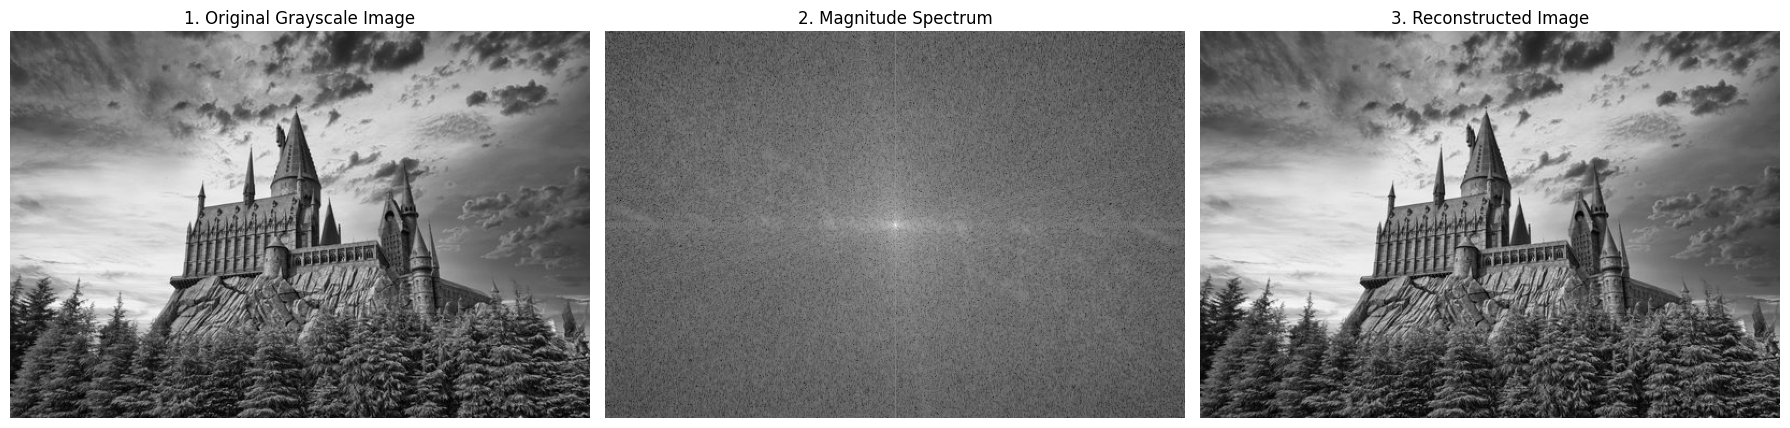

In [10]:
#plotting all three stages side-by-side using matplotlib
plt.figure(figsize=(18, 6))

# 1. original grayscale image
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('1. Original Grayscale Image')
plt.axis('off')

# 2. magnitude spectrum
plt.subplot(1, 3, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('2. Magnitude Spectrum')
plt.axis('off')

# 3. reconstructed image
plt.subplot(1, 3, 3)
plt.imshow(img_reconstructed, cmap='gray')
plt.title('3. Reconstructed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

**Note: Ideal Low-Pass Filtering in the Frequency Domain**

To demonstrate the power of the frequency domain, we will apply an Ideal Low-Pass Filter (ILPF).Low frequencies (concentrated at the center of our shifted spectrum) represent smooth regions and general contrast. High frequencies (towards the edges) represent sharp transitions like edges and noise.We will create a circular mask of radius $D_0$ centered on our spectrum. The mask function $H(u,v)$ is defined as:$$H(u, v) = \begin{cases} 1 & \text{if } D(u, v) \leq D_0 \\ 0 & \text{if } D(u, v) > D_0 \end{cases}$$

Where $D(u, v)$ is the distance from the center. Multiplying our shifted Fourier transform by this mask will zero out all high frequencies outside the circle.

In [14]:
#get the dimensions of the image to find the center
rows, cols = gray.shape
crow, ccol = rows // 2, cols // 2  #center coordinates

#define the cutoff radius for the low-pass filter (e.g., 60 pixels)
#smaller radius means more blurring; as fewer frequencies are allowed to pass.
radius = 80

#create a mask initialized with zeros (black)
mask = np.zeros((rows, cols), np.uint8)

#draw a filled white circle (1s) at the center to act as the pass-band
cv2.circle(mask, (ccol, crow), radius, 1, thickness=-1)

#apply the mask to the shifted frequency spectrum
#high frequencies outside the circle are multiplied by 0 and removed
f_shift_filtered = f_shift * mask

#calculate the magnitude spectrum of the FILTERED result (for visualization)
#we handle zero values to avoid log(0) warnings
magnitude_spectrum_filtered = 20 * np.log(np.abs(f_shift_filtered) + 1)

print("Low-Pass Filter mask applied")

Low-Pass Filter mask applied


**Reconstructing the Filtered Image**

Now that we have filtered out the high frequencies, we'll apply the inverse Fourier transform exactly as we did before to bring the image back to the spatial domain. We can expect the resulting image to look blurred because we removed the sharp edges.

Inverse transform of the filtered image completed

Reconstructed filtered image:


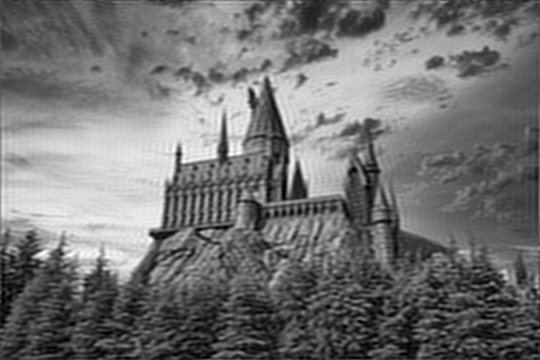

In [15]:
# 1. shift the zero-frequency component back to the top-left
f_ishift_filtered = np.fft.ifftshift(f_shift_filtered)

# 2. perform the Inverse 2D Fast Fourier Transform
img_back_complex_filtered = np.fft.ifft2(f_ishift_filtered)

# 3. extract the absolute magnitude to get the real spatial image
img_filtered_reconstructed = np.abs(img_back_complex_filtered)

print("Inverse transform of the filtered image completed")
print("\nReconstructed filtered image:")
cv2_imshow(img_filtered_reconstructed)

**Visualizing the Filter and Result**

Let's visualize the mask applied to the spectrum alongside the final reconstructed image. Notice how the loss of high-frequency data results in a smooth, blurred version of Hogwarts.

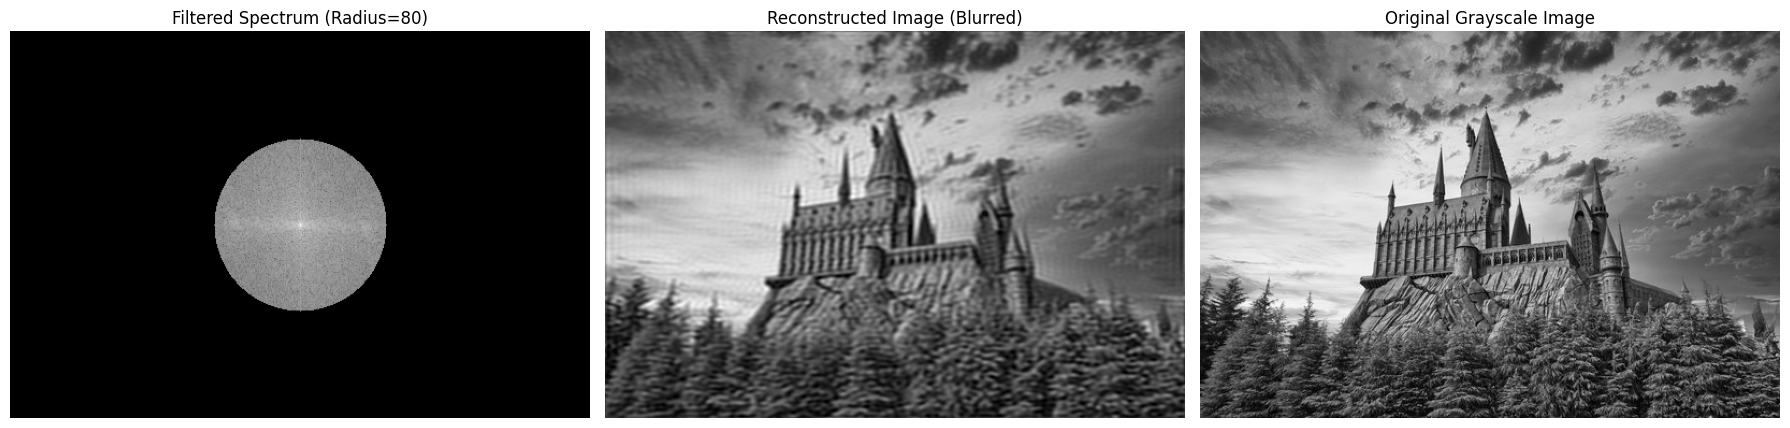

In [16]:
plt.figure(figsize=(18, 6))

# 1. filter mask applied to the spectrum
plt.subplot(1, 3, 1)
#we multiply the original magnitude spectrum by the mask to show what was kept
plt.imshow(magnitude_spectrum * mask, cmap='gray')
plt.title(f'Filtered Spectrum (Radius={radius})')
plt.axis('off')

# 2. reconstructed filtered image
plt.subplot(1, 3, 2)
plt.imshow(img_filtered_reconstructed, cmap='gray')
plt.title('Reconstructed Image (Blurred)')
plt.axis('off')

# 3. original (for comparison)
plt.subplot(1, 3, 3)
plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.tight_layout()
plt.show()